In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json
import csv
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# Training from scratch

In [4]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=training_dimensions, 
                                              normalize=True)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=40, 
    batch_size=64,
    lr=5e-4,
    device=device,
    train_transformer=True,
    patience=8,
)

Generating class with d=4, max_block_size=1...

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=12, max_block_size=1...Done.
Gener

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/40] | Train Loss: 0.636587 | Val Loss: 0.496211 | LR: 4.99e-04
Epoch [2/40] | Train Loss: 0.285358 | Val Loss: 0.353856 | LR: 4.97e-04
Epoch [3/40] | Train Loss: 0.234770 | Val Loss: 0.263215 | LR: 4.93e-04
Epoch [4/40] | Train Loss: 0.204506 | Val Loss: 0.264723 | LR: 4.88e-04
Epoch [5/40] | Train Loss: 0.185923 | Val Loss: 0.228427 | LR: 4.81e-04
Epoch [6/40] | Train Loss: 0.168117 | Val Loss: 0.206477 | LR: 4.73e-04
Epoch [7/40] | Train Loss: 0.152670 | Val Loss: 0.164813 | LR: 4.63e-04
Epoch [8/40] | Train Loss: 0.140323 | Val Loss: 0.148811 | LR: 4.52e-04
Epoch [9/40] | Train Loss: 0.140672 | Val Loss: 0.149059 | LR: 4.40e-04
Epoch [10/40] | Train Loss: 0.125271 | Val Loss: 0.130549 | LR: 4.27e-04
Epoch [11/40] | Train Loss: 0.120257 | Val Loss: 0.137372 | LR: 4.12e-04
Epoch [12/40] | Train Loss: 0.112461 | Val Loss: 0.148532 | LR: 3.97e-04
Epoch [13/40] | Train Loss: 0.111278 | Val Loss: 0.126991 | LR: 3.81e-04
Epoch [14/40] | Train Loss: 0.130901 | Val Loss: 0.133527 | 

# Tests

In [5]:
np.random.seed(123)
random.seed(123)
torch.manual_seed(123)

In [6]:
def run_test(model, d, matrices_per_class=10_000, mode="random", eps_range=(1e-8, 0.1), no_eps_rate=0.1):
    model.eval()

    chunk_size = 1000

    predicted_classes = []
    true_classes = []
    kl_losses = []
    E_norms_all = []
    rads_all = []
    S_conds_all = []

    # iterate over chunks
    for start in range(0, matrices_per_class, chunk_size):
        print(f"Testing: {d=}, {start=}")
        current_size = min(chunk_size, matrices_per_class - start)

        labels, features, dists, E_norms, S_conds, rads = generate_test_datasets(
            matrices_per_class=current_size,
            d=d,
            mode=mode,
            eps_range=eps_range,
            no_eps_rate=no_eps_rate,
            device="cpu",
            normalize=True,
        )

        loader = DataLoader(
            TensorDataset(features, labels, dists),
            batch_size=64,
            shuffle=False
        )

        true_classes.extend(labels.cpu().tolist())
        E_norms_all.extend([float(x.item()) for x in E_norms])
        rads_all.extend([float(x.item()) for x in rads])
        S_conds_all.extend([float(x.item()) for x in S_conds])

        for batch_features, batch_labels, batch_dists in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            batch_dists = batch_dists.to(device)

            logits = model(d, batch_features)
            loss = kl_loss(logits, batch_dists, reduction="none").sum(dim=-1)

            preds = torch.argmax(logits, dim=-1)
            predicted_classes.extend(preds.cpu().tolist())
            kl_losses.extend(loss.detach().cpu().tolist())

    return true_classes, predicted_classes, kl_losses, E_norms_all, S_conds_all, rads_all

def test_jordan_net(model, d, matrices_per_class=10_000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.csv"

    # ensure directory exists
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    true_classes, predicted_classes, kl_losses, E_norms, S_conds, rads = run_test(
        model=model,
        d=d,
        matrices_per_class=matrices_per_class
    )

    # basic sanity check (optional but helpful)
    n = len(true_classes)
    assert all(len(lst) == n for lst in [predicted_classes, kl_losses, E_norms, S_conds, rads]), \
        "All result lists must have the same length"

    with open(filename, mode="w", newline="") as f:
        writer = csv.writer(f)
        
        # header
        writer.writerow(["true_class", "pred_class", "kl_loss", "E_norm", "S_cond", "rad"])
        
        # rows
        for row in zip(true_classes, predicted_classes, kl_losses, E_norms, S_conds, rads):
            writer.writerow(row)

    return filename

In [7]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=10_000)

Testing: d=4, start=0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_17500\1293818312.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing: d=4, start=1000
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing: d=4, start=2000
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing: d=4, start=3000
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing: d=4, start=4000
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating

# Training + tests on additional dimensions

In [8]:
np.random.seed(345)
random.seed(345)
torch.manual_seed(345)

In [ ]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=1200,
                                                dimensions=[d], normalize=True)
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=40,
        batch_size=64,
        patience=8,
        lr=4e-4,
        device=device,
        train_transformer=False,
        history_filename=f"sandbox/history_jordan8_{d}.csv")

Generating class with d=35, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_17500\3359304159.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class with d=35, max_block_size=19...Done.
Generating class with d=35, ma

In [ ]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_11500\3686752702.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [ ]:
np.random.seed(123)
random.seed(123)
torch.manual_seed(123)

In [ ]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=10_000)

Testing: d=35, start=0
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating cla

# Test on $A \oplus 0$

In [ ]:
def run_test_oplus(model, d2, d1, matrices_per_class=10_000, mode="random", eps_range=(1e-8, 0.1), no_eps_rate=0.1):
    model.eval()

    chunk_size = 1000

    predicted_classes = []
    true_classes = []
    kl_losses = []
    E_norms_all = []
    rads_all = []
    S_conds_all = []

    # iterate over chunks
    for start in range(0, matrices_per_class, chunk_size):
        print(f"Testing: {d2=}, {start=}")
        current_size = min(chunk_size, matrices_per_class - start)

        labels, features, dists, E_norms, S_conds, rads = generate_test_datasets(
            matrices_per_class=current_size,
            d=(d2, d1),
            mode=mode,
            eps_range=eps_range,
            no_eps_rate=no_eps_rate,
            device="cpu",
            normalize=True,
        )

        loader = DataLoader(
            TensorDataset(features, labels, dists),
            batch_size=64,
            shuffle=False
        )

        true_classes.extend(labels.cpu().tolist())
        E_norms_all.extend([float(x.item()) for x in E_norms])
        rads_all.extend([float(x.item()) for x in rads])
        S_conds_all.extend([float(x.item()) for x in S_conds])

        for batch_features, batch_labels, batch_dists in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            batch_dists = batch_dists.to(device)

            logits = model(d1, batch_features)
            loss = kl_loss(logits, batch_dists, reduction="none").sum(dim=-1)

            preds = torch.argmax(logits, dim=-1)
            predicted_classes.extend(preds.cpu().tolist())
            kl_losses.extend(loss.detach().cpu().tolist())

    return true_classes, predicted_classes, kl_losses, E_norms_all, S_conds_all, rads_all

def test_jordan_net_oplus(model, d2, d1, matrices_per_class=10_000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d2}.csv"

    # ensure directory exists
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    true_classes, predicted_classes, kl_losses, E_norms, S_conds, rads = run_test_oplus(
        model=model,
        d2=d2,
        d1=d1,
        matrices_per_class=matrices_per_class
    )

    # basic sanity check (optional but helpful)
    n = len(true_classes)
    assert all(len(lst) == n for lst in [predicted_classes, kl_losses, E_norms, S_conds, rads]), \
        "All result lists must have the same length"

    with open(filename, mode="w", newline="") as f:
        writer = csv.writer(f)
        
        # header
        writer.writerow(["true_class", "pred_class", "kl_loss", "E_norm", "S_cond", "rad"])
        
        # rows
        for row in zip(true_classes, predicted_classes, kl_losses, E_norms, S_conds, rads):
            writer.writerow(row)

    return filename

In [ ]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_7036\3686752702.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mod

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [ ]:
np.random.seed(123)
random.seed(123)
torch.manual_seed(123)

In [ ]:
tested_dimensions = [(29, 33), (27, 28), (16, 19)]
for d2, d1 in tested_dimensions:
    test_jordan_net_oplus(model, d2, d1, matrices_per_class=10_000)

Testing: d2=29, start=0
Generating class with d=29, max_block_size=1...Done.
Generating class with d=29, max_block_size=2...Done.
Generating class with d=29, max_block_size=3...Done.
Generating class with d=29, max_block_size=4...Done.
Generating class with d=29, max_block_size=5...Done.
Generating class with d=29, max_block_size=6...Done.
Generating class with d=29, max_block_size=7...Done.
Generating class with d=29, max_block_size=8...Done.
Generating class with d=29, max_block_size=9...Done.
Generating class with d=29, max_block_size=10...Done.
Generating class with d=29, max_block_size=11...Done.
Generating class with d=29, max_block_size=12...Done.
Generating class with d=29, max_block_size=13...Done.
Generating class with d=29, max_block_size=14...Done.
Generating class with d=29, max_block_size=15...Done.
Generating class with d=29, max_block_size=16...Done.
Generating class with d=29, max_block_size=17...Done.
Generating class with d=29, max_block_size=18...Done.
Generating cl

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Testing: d2=29, start=1000
Generating class with d=29, max_block_size=1...Done.
Generating class with d=29, max_block_size=2...Done.
Generating class with d=29, max_block_size=3...Done.
Generating class with d=29, max_block_size=4...Done.
Generating class with d=29, max_block_size=5...Done.
Generating class with d=29, max_block_size=6...Done.
Generating class with d=29, max_block_size=7...Done.
Generating class with d=29, max_block_size=8...Done.
Generating class with d=29, max_block_size=9...Done.
Generating class with d=29, max_block_size=10...Done.
Generating class with d=29, max_block_size=11...Done.
Generating class with d=29, max_block_size=12...Done.
Generating class with d=29, max_block_size=13...Done.
Generating class with d=29, max_block_size=14...Done.
Generating class with d=29, max_block_size=15...Done.
Generating class with d=29, max_block_size=16...Done.
Generating class with d=29, max_block_size=17...Done.
Generating class with d=29, max_block_size=18...Done.
Generating

# Test results comparison

In [ ]:
def _load_state(path):
    sd = torch.load(path, map_location="cpu")
    # handle common checkpoint wrappers
    if isinstance(sd, dict) and ("state_dict" in sd or "model_state_dict" in sd):
        sd = sd.get("state_dict", sd.get("model_state_dict"))
    return sd

def _is_transformer_key(k):
    kl = k.lower()
    tokens = ("transformer", "transf", "encoder", "attn", "self_attn", "multihead", "mha", "ffn", "feed_forward")
    return any(t in kl for t in tokens)

p1 = "sandbox/model_jordan8.pth"
p2 = "sandbox/model_jordan8_modified.pth"

sd1 = _load_state(p1)
sd2 = _load_state(p2)

keys1 = set(sd1.keys())
keys2 = set(sd2.keys())

# collect transformer-related keys present in either checkpoint
t_keys = sorted(k for k in (keys1 | keys2) if _is_transformer_key(k))

if not t_keys:
    print("No transformer-related parameter names found in checkpoints.")
else:
    all_identical = True
    for k in t_keys:
        in1 = k in sd1
        in2 = k in sd2
        if not (in1 and in2):
            print(f"Mismatch presence: '{k}' only in", p1 if in1 else p2)
            all_identical = False
            continue

        a = sd1[k]
        b = sd2[k]
        if a.shape != b.shape:
            print(f"Shape differs for '{k}': {a.shape} vs {b.shape}")
            all_identical = False
            continue

        equal = torch.equal(a, b)
        max_abs = (a - b).abs().max().item() if a.numel() > 0 else 0.0
        mean_abs = (a - b).abs().mean().item() if a.numel() > 0 else 0.0
        status = "IDENTICAL" if equal else "DIFFER"
        print(f"{status}: {k} | max_abs={max_abs:.6e}, mean_abs={mean_abs:.6e}")
        if not equal:
            all_identical = False


IDENTICAL: encoders.12.net.0.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.0.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
Mismatch presence: 'encoders.13.net.0.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.0.weight' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.weight' only in sandbox/model_jordan8_modified.pth


C:\Users\micha\AppData\Local\Temp\ipykernel_21020\3512677630.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(path, map_location="cpu")


C:\Users\micha\AppData\Local\Temp\ipykernel_19196\4175081034.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

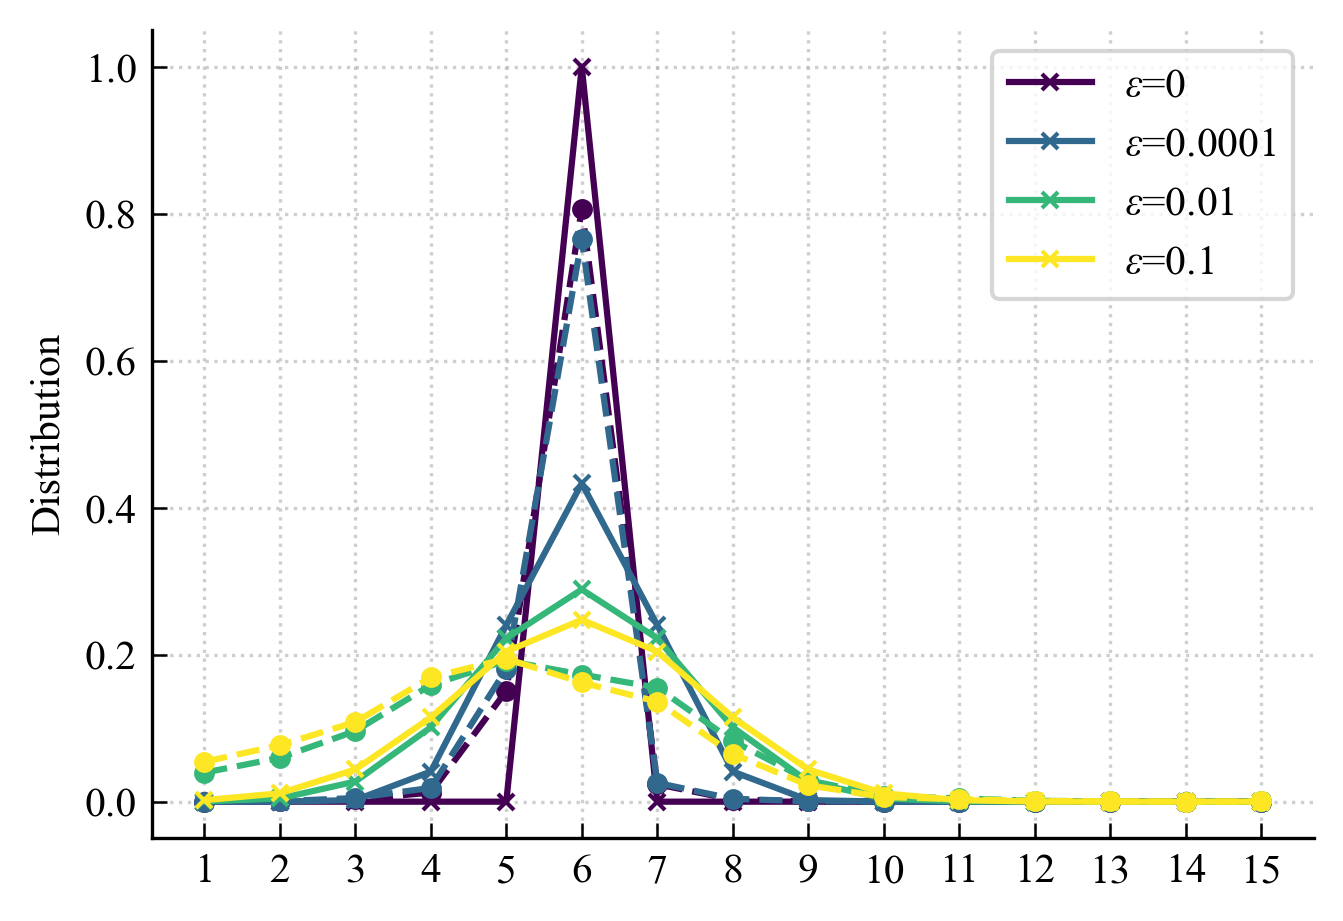

In [ ]:
max_block_size = 6
dtype = np.float32
d = 15

model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.cpu()
model.eval()

epsilons = [0, 1e-4, 1e-2, 1e-1]

Xs = [generate_matrix(d, max_block_size, mode="random", eps=eps)[0] for eps in epsilons]
X_batch = torch.tensor(Xs, dtype=torch.float32)
features = [per_power_features(X) for X in Xs]
X_features = torch.tensor(features, dtype=torch.float32)

logits = model(d, X_features)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(epsilons)))


for i, (prob, eps) in enumerate(zip(probs, epsilons)):
    c = colors[i]
    plt.plot(
        soft_target(torch.tensor([max_block_size]), eps=torch.tensor(eps), d=d)
        .cpu().numpy(),
        marker='x', linestyle='-', color=c, label=f"$\\varepsilon$={eps}",
    )
    plt.plot(
        prob,
        # label=f"$\\varepsilon$={eps}",
        marker='o', linestyle='--', color=c
    )

plt.legend()
plt.xticks(ticks=range(d), labels=range(1,d+1))
#plt.xlim(6,16)
plt.ylabel("Distribution")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_target_eample.pdf")
plt.show()
    